In [53]:
'''
# 🌾 Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 (2026–2027)

**Domain:** Data Analytics

**Objective:**
To analyze agricultural performance across Kharif, Rabi, and Zaid seasons
using environmental, resource, production, and economic indicators.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
'''

'\n# 🌾 Seasonal Agriculture Performance Analysis\n\n### VOIS AICTE Batch 1 (2026–2027)\n\n**Domain:** Data Analytics\n\n**Objective:**  \nTo analyze agricultural performance across Kharif, Rabi, and Zaid seasons\nusing environmental, resource, production, and economic indicators.\n\n### Tools Used\n- Python\n- Pandas\n- NumPy\n- Matplotlib\n- Seaborn\n- SciPy\n'

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [55]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

Saving Seasonal_Agriculture_Cleaned.csv to Seasonal_Agriculture_Cleaned (1).csv
File uploaded successfully!


In [56]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4000, 31)


In [57]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Is_Profitable
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,False
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,False
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,False
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,False
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,False


In [58]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Is_Profitable
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2,-562.886315,76889.194915,False
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7,80.665444,56610.148233,True
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2,-81.054155,75036.485196,False
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4,12.633969,88961.849711,True
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3,-17.264979,79719.637462,False


In [59]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 4000
Number of Columns: 31


In [60]:
print("Columns in the dataset:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns in the dataset:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct
29. Profit_Margin_pct
30. Cost_per_Hectare
31. Is_Profitable


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,5.000000e-01,4.260000,7.895000,11.650000,1.500000e+01
Rainfall_mm,4000.0,600.720675,288.420788,8.000000e+01,370.425000,581.000000,835.950000,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,1.620000e+01,23.900000,26.900000,29.600000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,2.500000e+01,54.775000,63.000000,71.900000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500000e+00,6.600000,7.300000,8.100000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200000e+00,6.260000,6.690000,7.140000,8.400000e+00
Soil_Moisture_pct,4000.0,26.505913,6.695965,8.000000e+00,21.700000,26.400000,31.300000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,4.000000e+01,98.500000,120.100000,141.225000,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,1.500000e+01,46.200000,57.500000,69.400000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,3.000000e+01,86.200000,105.100000,123.600000,2.000000e+02


In [63]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage


In [64]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [65]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 31)


In [66]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [67]:
impute_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for col in impute_columns:
    df[col] = df.groupby(["Season", "Crop"])[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after imputation:")
print(df[impute_columns].isnull().sum())

Missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [68]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [69]:
season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


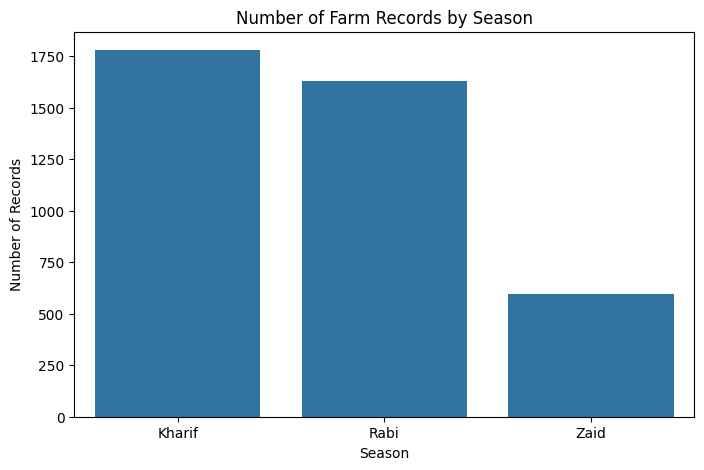

In [70]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [71]:
crop_counts = df["Crop"].value_counts()

print(crop_counts)

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


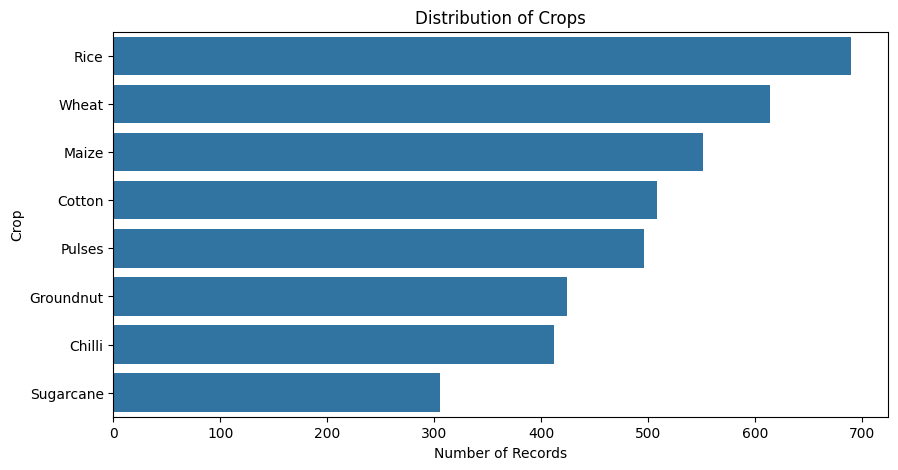

In [72]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

In [73]:
state_counts = df["State"].value_counts()

print(state_counts)

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


In [74]:
environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day"
]

season_environment = df.groupby("Season")[environmental_columns].mean()

season_environment = season_environment.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

season_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.103626,28.454019,71.812591,6.793367
Rabi,435.948156,23.489183,57.893178,7.589797
Zaid,299.162795,31.042088,52.012121,8.178788


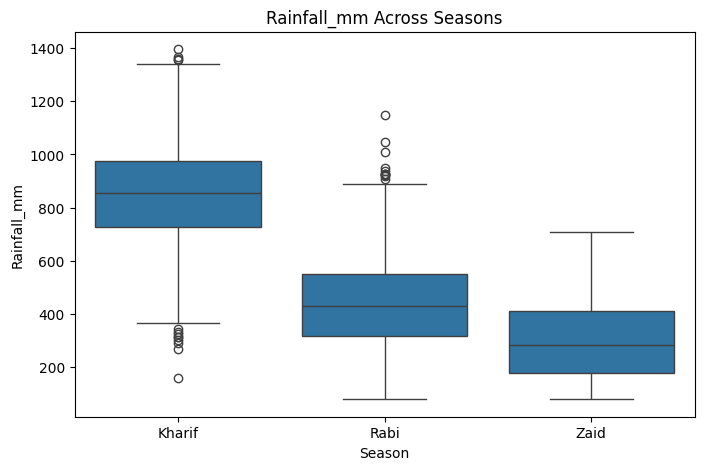

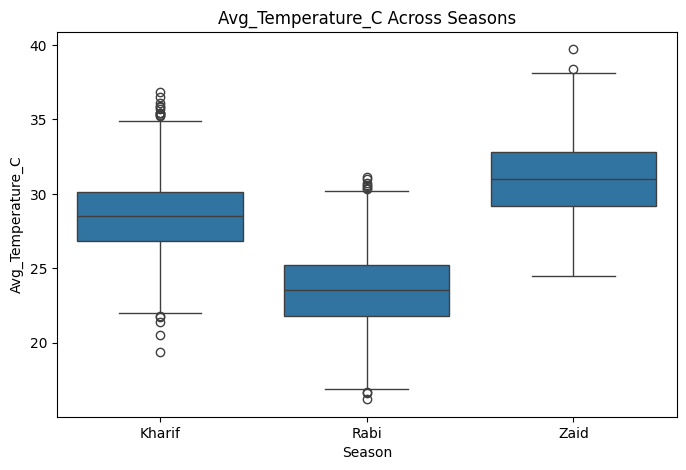

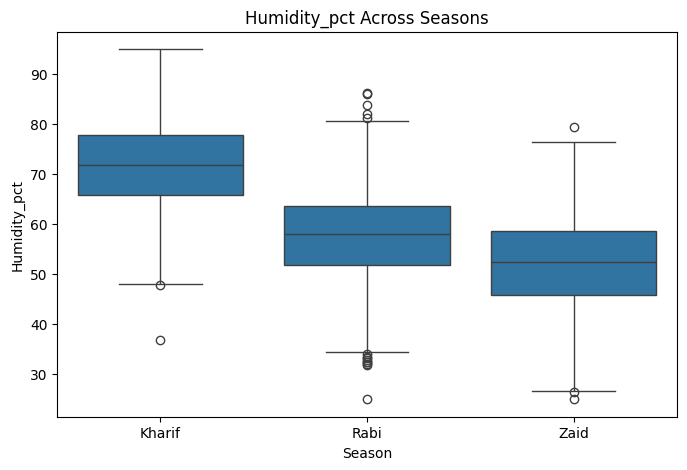

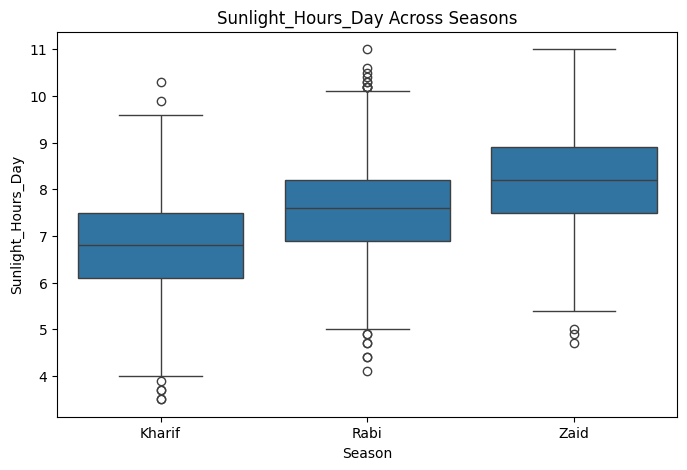

In [75]:
for col in environmental_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Season",
        y=col,
        order=["Kharif", "Rabi", "Zaid"]
    )

    plt.title(f"{col} Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(col)

    plt.show()

In [76]:
resource_columns = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

resource_summary = df.groupby("Season")[resource_columns].mean()

resource_summary = resource_summary.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

resource_summary

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.077965,5.079747,6102.201237,5.891834
Rabi,185.407068,5.024690,5846.987093,5.186122
Zaid,184.638047,5.171212,6419.893939,4.413239


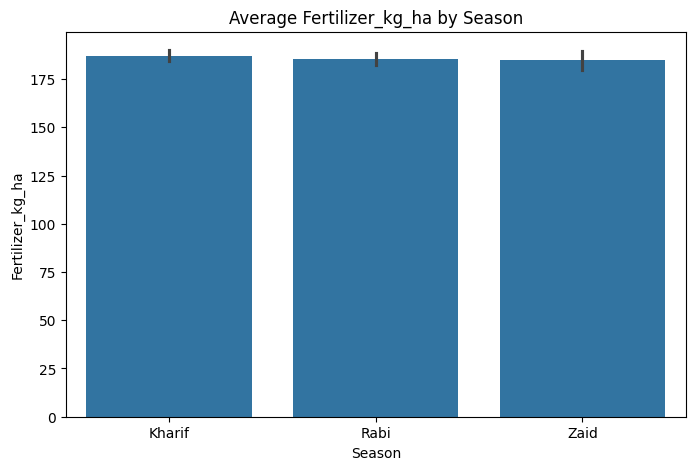

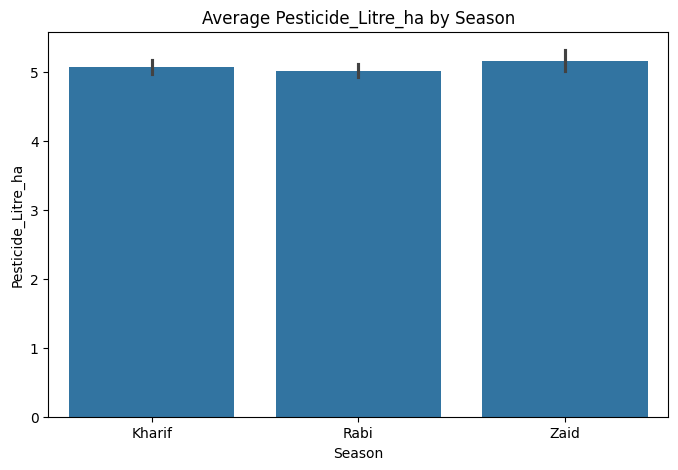

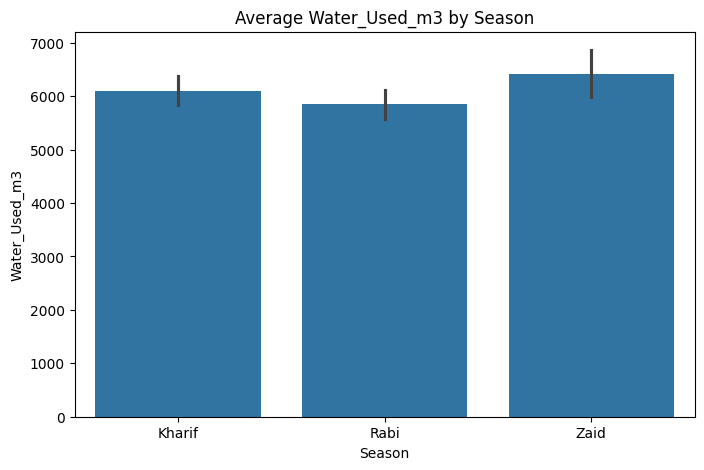

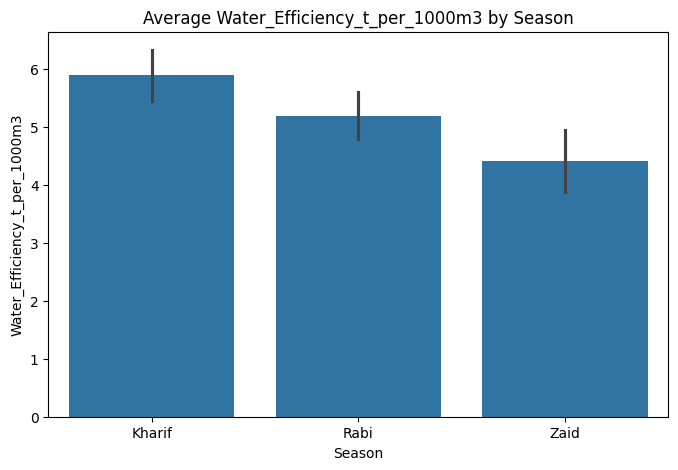

In [77]:
for col in resource_columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df,
        x="Season",
        y=col,
        order=["Kharif", "Rabi", "Zaid"],
        estimator="mean"
    )

    plt.title(f"Average {col} by Season")
    plt.xlabel("Season")
    plt.ylabel(col)

    plt.show()

In [78]:
irrigation_table = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"],
    normalize="index"
) * 100

irrigation_table

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.765599,33.164699,26.025857,18.043845
Rabi,22.741242,32.329441,26.920713,18.008605
Zaid,23.569024,32.659933,23.569024,20.202020


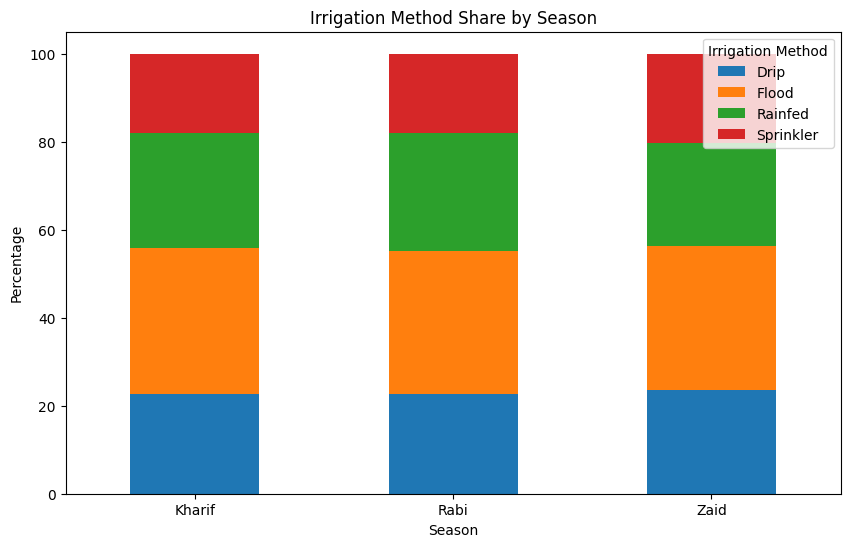

In [79]:
irrigation_table.reindex(
    ["Kharif", "Rabi", "Zaid"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Irrigation Method Share by Season")
plt.xlabel("Season")
plt.ylabel("Percentage")
plt.legend(title="Irrigation Method")
plt.xticks(rotation=0)
plt.show()

In [80]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield = crop_season_yield[
    ["Kharif", "Rabi", "Zaid"]
]

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731676,1.462822,1.179062
Cotton,1.373140,1.192985,0.951848
Groundnut,1.483834,1.222994,1.037778
Maize,2.966410,2.617489,2.297262
Pulses,1.036063,0.872019,0.652258
Rice,2.709268,2.334526,1.900490
Sugarcane,53.459120,43.963953,38.423922
Wheat,2.255788,2.059515,1.748588


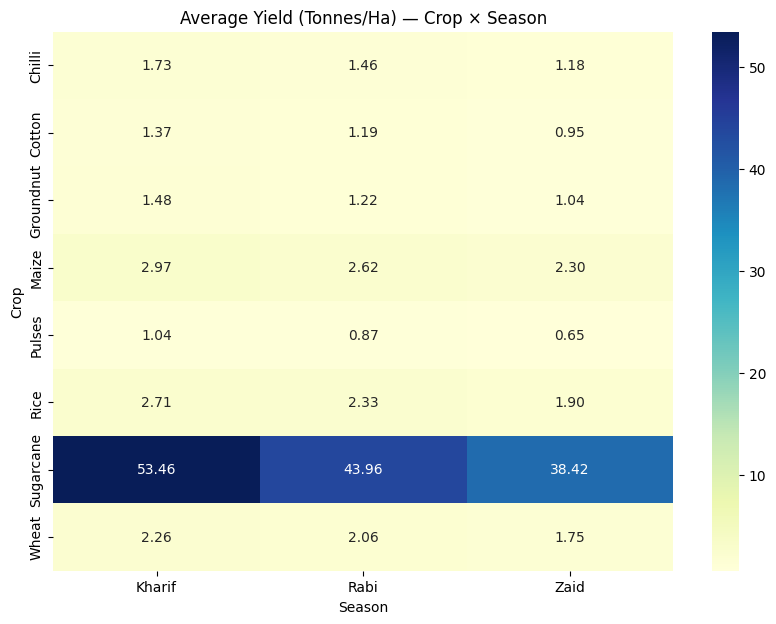

In [81]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield (Tonnes/Ha) — Crop × Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [82]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

season_yield = season_yield.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.630616
Rabi,5.094917
Zaid,4.637340


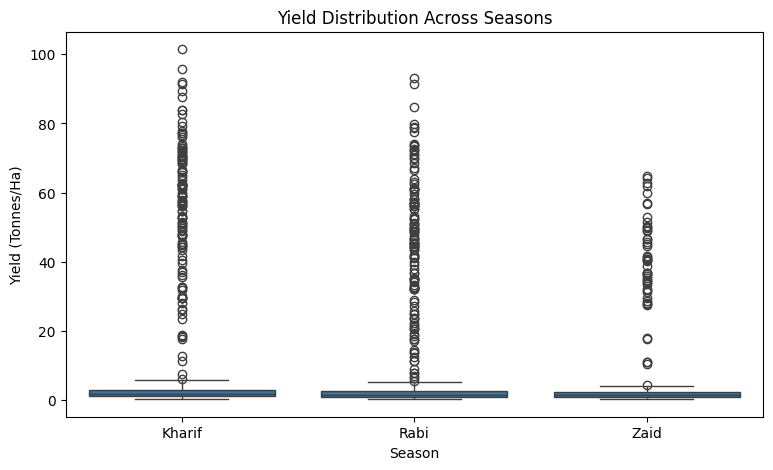

In [83]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [84]:
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    0
)

df["Cost_per_Hectare"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Total_Cost_INR"] / df["Farm_Area_Hectares"],
    0
)

df["Is_Profitable"] = df["Profit_INR"] > 0

print("Feature engineering completed!")

Feature engineering completed!


In [85]:
economic_columns = [
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Profit_Margin_pct"
]

economic_summary = df.groupby("Season")[economic_columns].mean()

economic_summary = economic_summary.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.408094,710719.055649,178914.647555,-38.644541
Rabi,513836.578365,601526.048556,87689.470191,-44.267645
Zaid,543976.728956,519171.904040,-24804.824916,-69.354573


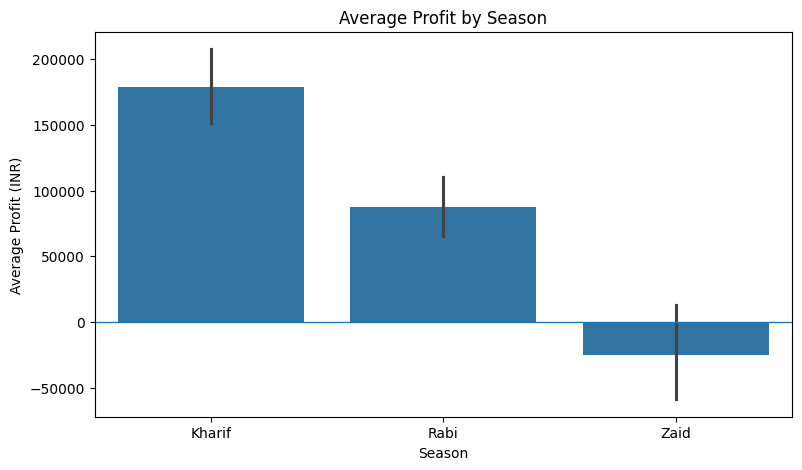

In [86]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.axhline(0, linewidth=1)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

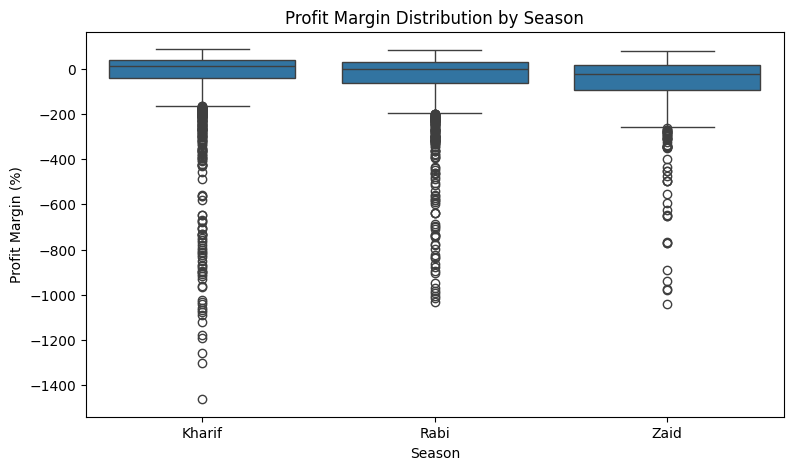

In [87]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_Margin_pct",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Profit Margin Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.show()

In [88]:
profitable_percentage = (
    df.groupby("Season")["Is_Profitable"]
    .mean() * 100
)

profitable_percentage = profitable_percentage.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

print(profitable_percentage)

Season
Kharif    57.785273
Rabi      48.862938
Zaid      35.521886
Name: Is_Profitable, dtype: float64


In [89]:
profit_status = pd.crosstab(
    df["Season"],
    df["Is_Profitable"],
    normalize="index"
) * 100

profit_status.columns = [
    "Loss-Making (%)",
    "Profitable (%)"
]

profit_status = profit_status.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

profit_status

,Loss-Making (%),Profitable (%)
Season,,
Kharif,42.214727,57.785273
Rabi,51.137062,48.862938
Zaid,64.478114,35.521886


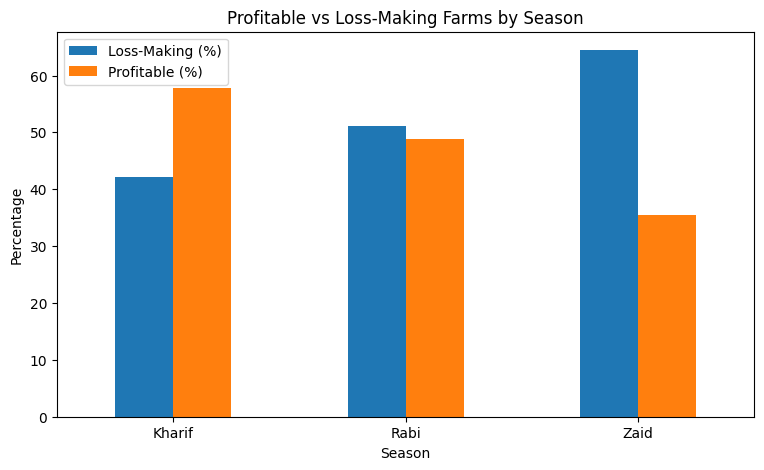

In [90]:
profit_status.reindex(
    ["Kharif", "Rabi", "Zaid"]
).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Profitable vs Loss-Making Farms by Season")
plt.xlabel("Season")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [91]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Yield_Tonnes_Ha",
    "Profit_Margin_pct"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Profit_Margin_pct
Rainfall_mm,1.000000,0.198494,0.526152,-0.366935,0.519830,0.005398,0.020958,0.030689,0.024626,0.001479,0.003151,0.056592,0.026858,0.059958
Avg_Temperature_C,0.198494,1.000000,0.138136,-0.033863,0.083258,0.018707,0.008508,0.022993,0.015861,0.006657,0.022995,0.006534,0.009153,-0.007474
Humidity_pct,0.526152,0.138136,1.000000,-0.297298,0.450652,0.001198,-0.005963,-0.003070,0.024623,-0.004028,-0.002086,0.026169,0.010651,0.028930
Sunlight_Hours_Day,-0.366935,-0.033863,-0.297298,1.000000,-0.304873,0.009920,0.001544,-0.014407,-0.013073,-0.017238,-0.005717,-0.021386,-0.015462,-0.036717
Soil_Moisture_pct,0.519830,0.083258,0.450652,-0.304873,1.000000,0.007605,0.014298,0.007931,0.007521,-0.022774,0.004504,0.027930,0.010065,0.051662
Nitrogen_kg_ha,0.005398,0.018707,0.001198,0.009920,0.007605,1.000000,0.010199,0.010490,-0.032440,0.014280,0.022127,0.054896,0.053633,0.040950
Phosphorus_kg_ha,0.020958,0.008508,-0.005963,0.001544,0.014298,0.010199,1.000000,0.002847,0.012905,-0.029942,-0.000752,0.057129,0.046685,0.052533
Potassium_kg_ha,0.030689,0.022993,-0.003070,-0.014407,0.007931,0.010490,0.002847,1.000000,0.017254,-0.004675,0.001667,0.006575,0.005127,0.006412
Fertilizer_kg_ha,0.024626,0.015861,0.024623,-0.013073,0.007521,-0.032440,0.012905,0.017254,1.000000,-0.001178,0.000895,0.005077,-0.000414,-0.054097
Pesticide_Litre_ha,0.001479,0.006657,-0.004028,-0.017238,-0.022774,0.014280,-0.029942,-0.004675,-0.001178,1.000000,0.002177,-0.006330,-0.008598,-0.020887


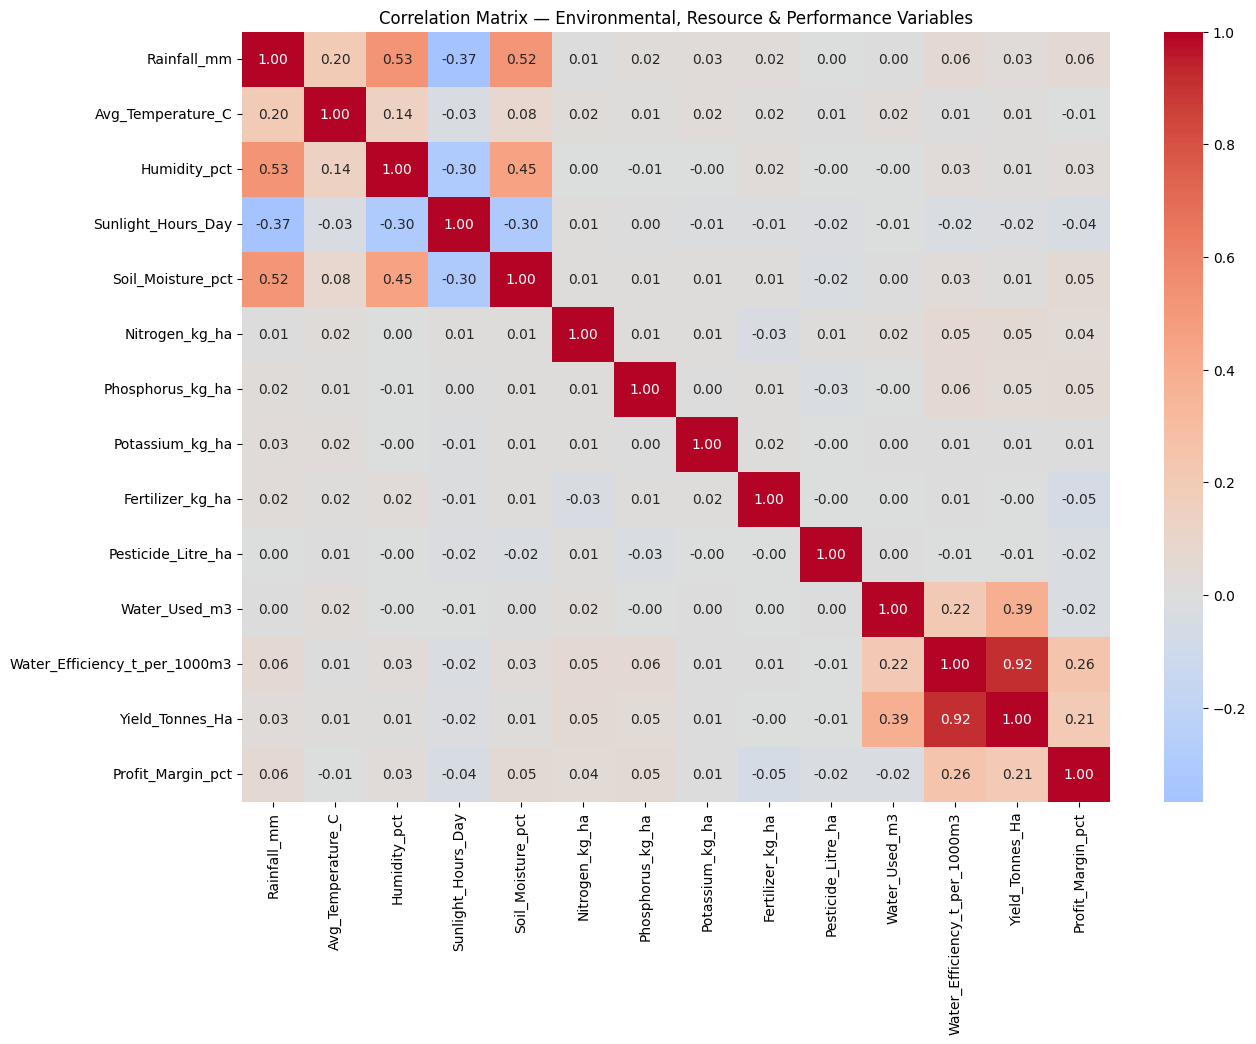

In [92]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Environmental, Resource & Performance Variables")
plt.show()

In [93]:
yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.915517
Water_Used_m3,0.387373
Profit_Margin_pct,0.205448
Nitrogen_kg_ha,0.053633
Phosphorus_kg_ha,0.046685
Rainfall_mm,0.026858
Humidity_pct,0.010651
Soil_Moisture_pct,0.010065
Avg_Temperature_C,0.009153
Potassium_kg_ha,0.005127


In [94]:
metrics = [
    "Yield_Tonnes_Ha",
    "Profit_Margin_pct",
    "Rainfall_mm",
    "Water_Efficiency_t_per_1000m3"
]

season_order = ["Kharif", "Rabi", "Zaid"]

results = []

for metric in metrics:

    groups = [
        df.loc[df["Season"] == season, metric].dropna()
        for season in season_order
    ]

    h_stat, p_value = kruskal(*groups)

    results.append({
        "Metric": metric,
        "H-Statistic": h_stat,
        "P-Value": p_value,
        "Significant": p_value < 0.05
    })

kruskal_results = pd.DataFrame(results)

kruskal_results

,Metric,H-Statistic,P-Value,Significant
0,Yield_Tonnes_Ha,70.264615,5.523735e-16,True
1,Profit_Margin_pct,98.062616,5.081284e-22,True
2,Rainfall_mm,2599.879454,0.000000e+00,True
3,Water_Efficiency_t_per_1000m3,56.811481,4.608332e-13,True


In [95]:
for _, row in kruskal_results.iterrows():

    if row["P-Value"] < 0.05:
        result = "Significant difference across seasons"
    else:
        result = "No significant difference across seasons"

    print(
        f"{row['Metric']}: "
        f"H = {row['H-Statistic']:.2f}, "
        f"p = {row['P-Value']:.5f} → {result}"
    )

Yield_Tonnes_Ha: H = 70.26, p = 0.00000 → Significant difference across seasons
Profit_Margin_pct: H = 98.06, p = 0.00000 → Significant difference across seasons
Rainfall_mm: H = 2599.88, p = 0.00000 → Significant difference across seasons
Water_Efficiency_t_per_1000m3: H = 56.81, p = 0.00000 → Significant difference across seasons


In [96]:
state_season_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="State",
    columns="Season",
    aggfunc="mean"
)

state_season_profit = state_season_profit[
    ["Kharif", "Rabi", "Zaid"]
]

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222
Punjab,133779.099548,169294.521505,62109.688312
Tamil Nadu,211303.956311,70456.860577,-15175.197183
Telangana,199668.380342,62824.604061,-34620.776471


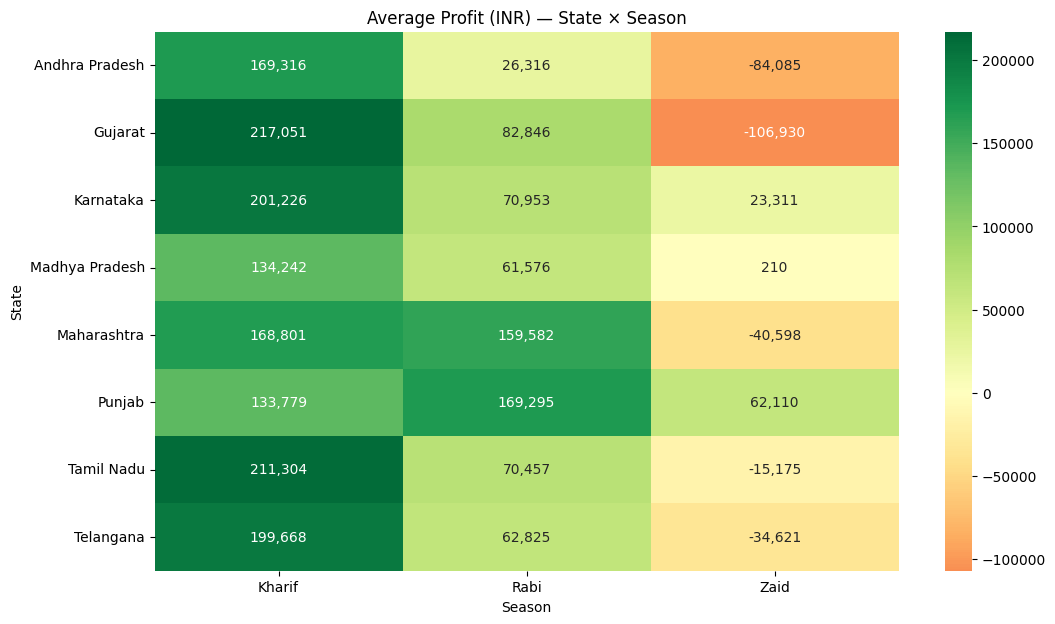

In [97]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=",.0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Profit (INR) — State × Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

In [98]:
disease_risk = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

disease_risk

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


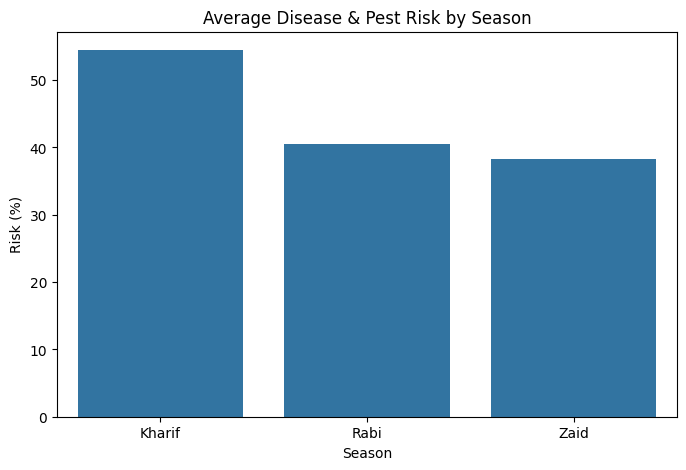

In [99]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=disease_risk.index,
    y=disease_risk.values
)

plt.title("Average Disease & Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

In [100]:
summary = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Profit_Margin=("Profit_Margin_pct", "mean"),
    Profitable_Farms=("Is_Profitable", "mean"),
    Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
)

summary["Profitable_Farms"] *= 100

summary = summary.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

summary

,Records,Avg_Yield,Avg_Water_Efficiency,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Profitable_Farms,Disease_Pest_Risk
Season,,,,,,,,,
Kharif,1779,5.630616,5.891834,531804.408094,710719.055649,178914.647555,-38.644541,57.785273,54.467903
Rabi,1627,5.094917,5.186122,513836.578365,601526.048556,87689.470191,-44.267645,48.862938,40.482114
Zaid,594,4.637340,4.413239,543976.728956,519171.904040,-24804.824916,-69.354573,35.521886,38.216667


In [101]:
best_yield_season = summary["Avg_Yield"].idxmax()
best_profit_season = summary["Avg_Profit"].idxmax()
best_water_efficiency_season = summary["Avg_Water_Efficiency"].idxmax()
lowest_profit_season = summary["Avg_Profit"].idxmin()

print("Highest average yield:", best_yield_season)
print("Highest average profit:", best_profit_season)
print("Highest water efficiency:", best_water_efficiency_season)
print("Lowest average profit:", lowest_profit_season)

Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif
Lowest average profit: Zaid


In [102]:
''' 🔍 Key Findings

1. Agricultural performance varies significantly across Kharif, Rabi and Zaid seasons.

2. Kharif shows the strongest overall yield and economic performance.

3. Yield generally declines from Kharif → Rabi → Zaid across individual crops.

4. Environmental conditions differ substantially between seasons, particularly rainfall,
   temperature and humidity.

5. Water efficiency has a strong positive relationship with yield.

6. Profitability varies considerably across seasons, with Zaid showing weaker economic performance.

7. Kharif has the highest disease and pest risk despite its stronger agricultural performance.

8. State-wise analysis shows that regional factors can influence seasonal outcomes.

9. Sugarcane has a much higher yield scale than other crops, so crop-wise comparisons
   should be used when interpreting yield patterns.

10. Statistical testing confirms that major seasonal differences are statistically significant.
'''

' 🔍 Key Findings\n\n1. Agricultural performance varies significantly across Kharif, Rabi and Zaid seasons.\n\n2. Kharif shows the strongest overall yield and economic performance.\n\n3. Yield generally declines from Kharif → Rabi → Zaid across individual crops.\n\n4. Environmental conditions differ substantially between seasons, particularly rainfall,\n   temperature and humidity.\n\n5. Water efficiency has a strong positive relationship with yield.\n\n6. Profitability varies considerably across seasons, with Zaid showing weaker economic performance.\n\n7. Kharif has the highest disease and pest risk despite its stronger agricultural performance.\n\n8. State-wise analysis shows that regional factors can influence seasonal outcomes.\n\n9. Sugarcane has a much higher yield scale than other crops, so crop-wise comparisons\n   should be used when interpreting yield patterns.\n\n10. Statistical testing confirms that major seasonal differences are statistically significant.\n'

In [103]:
'''
## 💡 Recommendations

### 1. Season-Specific Resource Planning
Adjust fertilizer, irrigation and water-management strategies according to seasonal conditions.

### 2. Improve Water Efficiency
Promote efficient irrigation practices and better water management.

### 3. Target Zaid-Season Losses
Investigate cost reduction and crop-selection strategies for the Zaid season.

### 4. Strengthen Kharif Crop Protection
Because Kharif has higher disease and pest risk, proactive crop-protection strategies
should be considered.

### 5. Crop-Season Matching
Use crop-wise seasonal performance to support better crop planning.

### 6. Region-Specific Analysis
Investigate states that differ from the general seasonal trend to identify transferable
agricultural practices.
'''

'\n## 💡 Recommendations\n\n### 1. Season-Specific Resource Planning\nAdjust fertilizer, irrigation and water-management strategies according to seasonal conditions.\n\n### 2. Improve Water Efficiency\nPromote efficient irrigation practices and better water management.\n\n### 3. Target Zaid-Season Losses\nInvestigate cost reduction and crop-selection strategies for the Zaid season.\n\n### 4. Strengthen Kharif Crop Protection\nBecause Kharif has higher disease and pest risk, proactive crop-protection strategies\nshould be considered.\n\n### 5. Crop-Season Matching\nUse crop-wise seasonal performance to support better crop planning.\n\n### 6. Region-Specific Analysis\nInvestigate states that differ from the general seasonal trend to identify transferable\nagricultural practices.\n'

In [104]:
'''
## 📝 Conclusion

The analysis of agricultural records across Kharif, Rabi and Zaid seasons demonstrates
that agricultural performance varies significantly with seasonal conditions.

Kharif emerges as the strongest season in terms of yield and profitability, while Zaid
shows weaker economic performance. Environmental conditions, resource usage,
water efficiency and disease-pest risk also vary across seasons.

The statistical analysis confirms that seasonal differences in important agricultural
metrics are significant.

Overall, the findings demonstrate how data analytics can support season-aware
agricultural planning, efficient resource allocation and improved decision-making.
'''

'\n## 📝 Conclusion\n\nThe analysis of agricultural records across Kharif, Rabi and Zaid seasons demonstrates\nthat agricultural performance varies significantly with seasonal conditions.\n\nKharif emerges as the strongest season in terms of yield and profitability, while Zaid\nshows weaker economic performance. Environmental conditions, resource usage,\nwater efficiency and disease-pest risk also vary across seasons.\n\nThe statistical analysis confirms that seasonal differences in important agricultural\nmetrics are significant.\n\nOverall, the findings demonstrate how data analytics can support season-aware\nagricultural planning, efficient resource allocation and improved decision-making.\n'

In [105]:
output_file = "Seasonal_Agriculture_Cleaned.csv"

df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [106]:
from google.colab import files

files.download("Seasonal_Agriculture_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
summary.to_csv("Seasonal_Agriculture_Summary.csv")

print("Summary exported successfully!")

Summary exported successfully!
